> **v2: next-month forecast.** Identical to v1 (same features, models, split and cross-validation) with one fix: every feature is **lagged one month**, so month *t*'s CPI change is predicted only from data available by the end of month *t−1*. In v1, `CPI_YoY` and same-month PPI/oil/food changes leaked the answer.
>
> **Result:** test R² falls from 0.39 (v1) to **−0.20** for Lasso, −0.50 for Ridge and −2.46 for OLS. Lasso's test MSE (0.0210) is on par with naive benchmarks: train mean 0.0199, trailing 12-month mean 0.0212, last month 0.0294 (`scripts/baselines.py`). Once only past data is used, these macro features carry little next-month signal.

# HMW4- Pre MFE - ML

## Summary: 

The following report presents three linear models attempting to predict monthly CPI inflation (CPI month-over-month percentage change). Data was sourced exclusively from the Federal Reserve Economic Data (FRED) database, covering the period from January 2005 to December 2025. A selection of macroeconomic features spanning monetary policy, cost-push dynamics, real economic activity, and demand-side signals were engineered into stationary transformations and fed into three regression models: Ordinary Least Squares, Ridge, and Lasso.

Feature engineering prioritized stationarity — raw non-stationary level variables were replaced by growth rates, percentage changes, and first differences to avoid spurious correlations driven by shared trends. PPI was introduced as a novel feature beyond the suggested list, capturing producer-level cost pass-through to consumer prices with a 2-3 month transmission lag. Alpha selection for Ridge and Lasso used TimeSeriesSplit cross-validation to respect the temporal ordering of the data and avoid leakage.

Lasso achieved the highest R² on the held-out test set (2023–present), confirming that sparse feature selection is advantageous for a noisy target like monthly CPI changes. Ridge followed closely, while OLS underperformed due to its sensitivity to noise and multicollinearity in the absence of regularization. Residual analysis via Shapiro-Wilk testing confirmed approximate normality for all three models, while a bias test identified a statistically significant directional error in Ridge — attributed to regime shift between the training and test periods. Prediction uncertainty was quantified using bootstrap resampling, producing time-varying confidence bands that do not rely on distributional assumptions.

In [1]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV, LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from scipy import stats
from sklearn.utils import resample
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "../data/fred_monthly.csv"   # built by scripts/fetch_fred.py (no API key needed)
START_DATE = "2005-01-01"
TRAIN_END = "2022-12-31"
TEST_START = "2023-01-01"
END_DATE = "2025-12-31"   # same test window as the original submission

It interesting to observe the CPI prediction problem through two different lenses: the macro overview and the cost-push approach. The macroeconomic approach considers monetary policies and accounts for interest rates, money supply (M2), GPD, and output gaps -which are simple the difference between the actual and potential economic outputs, in other words: GDP. On the other hand exchange rates around the world, taking USD as a base currency, affects global trades and is closely linked to imports and exports of tradeable good, impacting the end user of a given product or service. Shipping costs, commodity prices, food related items, credit and debit card transaction weights are all example of potential CPI predictors. 

Historically, it is also documented that CPI historical trends gives insights regarding future CPI prediction levels. 

The following code defines the data series to pull from FRED. This is followed by some feature engineering in order to build stationary, cleaned, splitted and ready data to be fed in the models. A definition of correlation analysis was also found useful to add. 

In [3]:
def pull_fred(series_dict: dict, api_key: str, start: str, end: str) -> pd.DataFrame:
    from fredapi import Fred
    fred = Fred(api_key=api_key)

    frames = {}
    for col_name, series_id in series_dict.items():
        print(f" Pulling {col_name} ({series_id})...")
        try:
            s = fred.get_series(series_id, observation_start=start, observation_end=end)
            s = s.resample("ME").last().ffill() #ME is month_end
            frames[col_name] = s
        except Exception as e:
            print(f"  WARNING: Could not pull {col_name}: {e}")

    df = pd.DataFrame(frames)
    df.index = pd.to_datetime(df.index).to_period("M").to_timestamp("M")
    return df


FRED_SERIES = {
    "CPI":          "CPIAUCSL",      #the consumer price index
    "FedFunds":     "FEDFUNDS",      #federal funds rate as a signal to monetary policies
    "M2_nominal":   "M2SL",          #money supply (leads CPI ~12-18mo based on resources)
    "GDP_real":     "GDPC1",         #real GDP (quarterly)
    "GDP_potential":"GDPPOT",        #Potential GDP (quarterly)
    "UnempRate":    "UNRATE",        #based on Phillips Curve dynamic demand-side pressure
    "ExchangeRate": "DTWEXBGS",      #trade weighted USD index (import price inflation)
    "OilPrice":     "DCOILWTICO",    #energy cost-push dynamic (daily to month-end) 
    "ImportPrices": "IR",            #import price index (related to exchange rate)
    "FoodPPI":      "WPU012",        #food price index
    "RetailSales":  "RSXFS",         #consumer demand proxy
    "WageGrowth":   "CES0500000003", #demand-pull inflation / wage-price spiral
    "PPI_AllCommodities": "PPIACO",  #producer level input cost
    "PCE":              "PCE",       #broader demand signal compared to retail
    "CreditSpread":     "BAA10Y",    #financial stress and credit tightening signal
}

def load_fred(path: str, start: str, end: str) -> pd.DataFrame:
    """Monthly panel saved by scripts/fetch_fred.py (FRED public CSV, no API key).
    Same treatment as pull_fred: month-end values, forward-filled."""
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    return df.loc[start:end].ffill()


It is important to build relevant features in order to counter the issue non-stationary data. Non-stationary features cause spurious correlations in models and tend to provide trend based prediction rather than identifying and providing actual signal. 


This is the reason why the following features engineered attempt to provide a relevant baseline that will be further filtered to avoid issues like multicolinearity and redundancies. 

In [4]:
def compute_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    #MoM and YoY changes useful for analysis
    out["CPI_MoM"] = out["CPI"].pct_change(1) * 100     
    out["CPI_YoY"] = out["CPI"].pct_change(12) * 100 #= inflation rate

    #money supply growth with multiple monetary lags evaluation
    out["M2_real"] = out["M2_nominal"] / out["CPI"] * 100 
    m2_growth = out["M2_nominal"].pct_change(12) * 100
    out["M2_growth"]       = m2_growth
    out["M2_growth_lag6"]  = m2_growth.shift(6)   
    out["M2_growth_lag12"] = m2_growth.shift(12) 
    out["M2_growth_lag18"] = m2_growth.shift(18)

    #real M2 based on nominal, inflation adjusted
    out["M2_real"] = out["M2_nominal"] / out["CPI"] * 100

    #measure of economical 'heat' or 'cooling' for inflationary pressure
    out["OutputGap"] = (out["GDP_real"] - out["GDP_potential"]) / out["GDP_potential"] * 100

    #YoY real GDP growth (quarterly)
    out["GDP_growth"] = out["GDP_real"].pct_change(4) * 100

    #measure of cost push inflation based on dollar level and imports expenses using changes
    out["FX_change_3m"]  = out["ExchangeRate"].pct_change(3) * 100
    out["FX_change_12m"] = out["ExchangeRate"].pct_change(12) * 100

    #cost-push inflation through energy component and transport costs with lag
    out["Oil_MoM"]  = out["OilPrice"].pct_change(1) * 100
    out["Oil_YoY"]  = out["OilPrice"].pct_change(12) * 100
    out["Oil_lag2"] = out["OilPrice"].shift(2)
    out["Oil_lag3"] = out["OilPrice"].shift(3)

    #producier prices lead consumer prices if not absorbed 
    out["PPI_MoM"]  = out["PPI_AllCommodities"].pct_change(1) * 100
    out["PPI_YoY"]  = out["PPI_AllCommodities"].pct_change(12) * 100
    out["PPI_lag2"] = out["PPI_AllCommodities"].shift(2)
    out["PPI_lag3"] = out["PPI_AllCommodities"].shift(3)

    #import prices are also cost-push inflation features
    out["Import_YoY"] = out["ImportPrices"].pct_change(12) * 100
    out["Import_lag3"] = out["ImportPrices"].shift(3)

    #autoregressive feature, CPI lags (caputre momentum and mean-reversion characteristics)
    for lag in [1, 2, 3, 6, 12]:
        out[f"CPI_lag{lag}"] = out["CPI"].shift(lag)
        
    #federal funds rate and changes -signal for direction of easing or tightening
    out["FedFunds_change"] = out["FedFunds"].diff(1)
    out["FedFunds_lag3"]   = out["FedFunds"].shift(3)
    out["FedFunds_lag6"]   = out["FedFunds"].shift(6)

    #direction of unemployment
    out["Unemp_change"] = out["UnempRate"].diff(1)

    #retail sales and PCE changes
    out["Retail_YoY"] = out["RetailSales"].pct_change(12) * 100
    out["PCE_YoY"]    = out["PCE"].pct_change(12) * 100

    #credit spread change measuring level of financial stress and direction
    out["CreditSpread_change"] = out["CreditSpread"].diff(1)

    # Food prices — YoY change
    out["FoodPPI_YoY"] = out["FoodPPI"].pct_change(12) * 100
    out["FoodPPI_MoM"] = out["FoodPPI"].pct_change(1) * 100
    
    # Wage growth — already a growth rate but convert to YoY change
    out["Wage_YoY"] = out["WageGrowth"].pct_change(12) * 100

    out["CPI_YoY_lag1"] = out["CPI_YoY"].shift(1)
    out["CPI_YoY_lag3"] = out["CPI_YoY"].shift(3)
    out["CPI_YoY_lag6"] = out["CPI_YoY"].shift(6)

    out["CPI_MoM_lag1"] = out["CPI_MoM"].shift(1)
    out["CPI_MoM_lag3"] = out["CPI_MoM"].shift(3)
    out["CPI_MoM_lag6"] = out["CPI_MoM"].shift(6)

    return out

In [5]:
def clean_and_split(df: pd.DataFrame, train_end: str, test_start: str):
    df = df[df.index >= "2008-01-01"].copy()
    df = df.dropna(axis=1, how="all")
    df = df.ffill(limit=2)
    df = df.dropna(subset=["CPI_MoM"])
    nan_report = df.isnull().sum()
    nan_report = nan_report[nan_report > 0]
    if len(nan_report) > 0:
        print("\nRemaining NaNs per column (will be dropped row-wise):")
        print(nan_report.to_string())
    df = df.dropna()

    print(f"\nFinal dataset: {len(df)} rows from {df.index.min()} to {df.index.max()}")

    train = df[df.index <= train_end]
    test  = df[df.index >= test_start]

    print(f"\n  Full dataset : {len(df)} rows  ({df.index.min().date()} → {df.index.max().date()})")
    print(f"  Train        : {len(train)} rows ({train.index.min().date()} → {train.index.max().date()})")
    print(f"  Test         : {len(test)} rows  ({test.index.min().date()} → {test.index.max().date()})")

    return df, train, test

In [6]:
def correlation_analysis(df: pd.DataFrame, target: str = "CPI_MoM", top_n: int = 20) -> pd.DataFrame:
    feature_cols = [c for c in df.columns if c not in [target, "CPI_YoY"]]
    corr = df[feature_cols + [target]].corr()[target].drop(target)
    corr_df = (
        pd.DataFrame({"correlation": corr})
        .assign(abs_corr=lambda x: x["correlation"].abs())
        .sort_values("abs_corr", ascending=False)
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    print(f"\n  Top {top_n} features correlated with {target}:")
    print(corr_df.head(top_n).to_string(index=False))

    top = corr_df.head(top_n)
    colors = ["#d62728" if v < 0 else "#1f77b4" for v in top["correlation"]]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top["feature"][::-1], top["correlation"][::-1], color=colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Pearson Correlation with CPI")
    ax.set_title(f"Top {top_n} Feature Correlations with CPI")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("cpi_correlations.png", dpi=150)
    plt.close()
    print("  Saved: cpi_correlations.png")

    return corr_df

As explained earlier, the two previous codes snippets clean, split and measure the correlation of the features based on month-on-month CPI. 

The output of the following code shows the data split for train and test between 2008-01-31 and 2022-12-31 and between 2023-01-31 and 2025-12-31 respectively. Non-stationary features were dropped as they are a mixed on trending, seasonal or not, data types. 

Finally, a list of the selected features is given. 

In [7]:
if __name__ == "__main__":

    print("=" * 60)
    print("CPI DATA PIPELINE — FRED ONLY")
    print("=" * 60)

    # 1. Pull
    df_raw = load_fred(DATA_PATH, START_DATE, END_DATE)

    # 2. Features
    df_feat = compute_derived_features(df_raw)
    #to avoid using non-stationary data that would cause spurious correlation 
    #let's clean it before splitting
    df_feat = df_feat.drop(['CPI', 'FedFunds', 'M2_nominal', 'GDP_real', 'GDP_potential',
                  'UnempRate', 'ExchangeRate', 'ImportPrices', 'FoodPPI',
                  'RetailSales', 'WageGrowth', 'OilPrice', 'PPI_AllCommodities', 'PCE',
                  'CreditSpread', 'M2_real', 'Oil_lag2', 'Oil_lag3', 'PPI_lag2', 'PPI_lag3',
                 'Import_lag3', 'FedFunds_lag3', 'FedFunds_lag6', 'CPI_lag1', 'CPI_lag2', 'CPI_lag3',
                  'CPI_lag6', 'CPI_lag12'], axis=1)
    # v2 fix: predict month t from information available at the end of month t-1.
    # Every feature moves down one row; the target (CPI_MoM) stays in place.
    target = df_feat["CPI_MoM"]
    df_feat = df_feat.drop(columns=["CPI_MoM"]).shift(1)
    df_feat.insert(0, "CPI_MoM", target)
    print(f"  Feature matrix: {df_feat.shape[1]} columns")

    # 3. Clean + split
    df_full, df_train, df_test = clean_and_split(df_feat, TRAIN_END, TEST_START)

    # 4. Correlations
    print("Correlation analysis...")
    corr_df = correlation_analysis(df_full, target="CPI_MoM", top_n=10)

    print("\nFEATURE LIST:")
    for i, col in enumerate(df_full.columns):
        print(f"  {i+1:02d}. {col}")

CPI DATA PIPELINE — FRED ONLY
  Feature matrix: 29 columns

Final dataset: 216 rows from 2008-01-31 00:00:00 to 2025-12-31 00:00:00

  Full dataset : 216 rows  (2008-01-31 → 2025-12-31)
  Train        : 180 rows (2008-01-31 → 2022-12-31)
  Test         : 36 rows  (2023-01-31 → 2025-12-31)
Correlation analysis...

  Top 10 features correlated with CPI_MoM:
            feature  correlation  abs_corr
            PPI_MoM     0.562028  0.562028
            Oil_MoM     0.522588  0.522588
CreditSpread_change    -0.458553  0.458553
       FX_change_3m    -0.408721  0.408721
            Oil_YoY     0.376027  0.376027
            PCE_YoY     0.362925  0.362925
         Retail_YoY     0.353095  0.353095
    M2_growth_lag12     0.307482  0.307482
            PPI_YoY     0.289485  0.289485
    FedFunds_change     0.274868  0.274868


  Saved: cpi_correlations.png

FEATURE LIST:
  01. CPI_MoM
  02. CPI_YoY
  03. M2_growth
  04. M2_growth_lag6
  05. M2_growth_lag12
  06. M2_growth_lag18
  07. OutputGap
  08. GDP_growth
  09. FX_change_3m
  10. FX_change_12m
  11. Oil_MoM
  12. Oil_YoY
  13. PPI_MoM
  14. PPI_YoY
  15. Import_YoY
  16. FedFunds_change
  17. Unemp_change
  18. Retail_YoY
  19. PCE_YoY
  20. CreditSpread_change
  21. FoodPPI_YoY
  22. FoodPPI_MoM
  23. Wage_YoY
  24. CPI_YoY_lag1
  25. CPI_YoY_lag3
  26. CPI_YoY_lag6
  27. CPI_MoM_lag1
  28. CPI_MoM_lag3
  29. CPI_MoM_lag6


The following part of the modelisation defines the train and test datasets between predictors and target features. 

The use of multicollinearity filtering was used in order redundancy between feature and other types of data transformation were subject to testing.

In [8]:

X_train = df_train.drop(columns=["CPI_MoM"])
X_test = df_test.drop(columns=["CPI_MoM"])
y_train = df_train["CPI_MoM"]
y_test = df_test["CPI_MoM"]

X = df_full.drop(columns=["CPI_MoM"])
y = df_full["CPI_MoM"]

In [9]:
#dealing with multicollinearity 

def remove_collinear_features(X: pd.DataFrame, threshold: float = 0.90) -> pd.DataFrame:
    dropped = []

    while True:
        corr_matrix = X.corr().abs()

        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        high_corr = (
            upper.stack()
            .reset_index()
            .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "corr"})
            .query("corr > @threshold")
            .sort_values("corr", ascending=False)
        )

        if high_corr.empty:
            break

        to_drop = high_corr.iloc[0]["feature_2"]
        f1      = high_corr.iloc[0]["feature_1"]
        corr_val = high_corr.iloc[0]["corr"]

        print(f"  Dropping '{to_drop}' (corr={corr_val:.3f} with '{f1}')")
        X = X.drop(columns=[to_drop])
        dropped.append(to_drop)

    print(f"\n  Removed {len(dropped)} collinear features at threshold={threshold}")
    print(f"  Remaining features: {X.shape[1]}")
    return X

In [10]:
#multicollinearity filtered data
THRESHOLD = 0.80
X_train_filtered = remove_collinear_features(X_train, threshold=THRESHOLD) #using X_train to avoid leakage

  Dropping 'CPI_YoY_lag1' (corr=0.975 with 'CPI_YoY')
  Dropping 'Import_YoY' (corr=0.906 with 'PPI_YoY')
  Dropping 'PPI_YoY' (corr=0.900 with 'CPI_YoY')
  Dropping 'CPI_YoY_lag3' (corr=0.860 with 'CPI_YoY')
  Dropping 'PCE_YoY' (corr=0.829 with 'Retail_YoY')

  Removed 5 collinear features at threshold=0.8
  Remaining features: 23


In [11]:
X_test_filtered = X_test[X_train_filtered.columns]

In [12]:
#prepare scaled features for Ridge and Lasso

scaler_full = StandardScaler()
X_train_scaled_full = scaler_full.fit_transform(X_train)
X_test_scaled_full  = scaler_full.transform(X_test)

In [13]:
#scaled mutlicollinearity filtered data
scaler_filt = StandardScaler()
X_train_scaled_filt = scaler_filt.fit_transform(X_train_filtered)
X_test_scaled_filt  = scaler_filt.transform(X_test_filtered)

In [14]:
#highly correlated data selection
corr_with_cpi = X_train.corrwith(y_train).abs().sort_values(ascending=False)

selected_features = corr_with_cpi[corr_with_cpi > 0.50].index.tolist()

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

#highly correlated data scaled 
scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled  = scaler_sel.transform(X_test_sel)

The different datasets are:

- X_train, X_test
- X_train_filtered, X_test_filtered
- X_train_scaled_full, X_test_scaled_full
- X_train_scaled_filt, X_test_scaled_filt
- X_train_sel, X_test_sel
- X_train_sel_scaled, X_test_sel_scaled

## Linear Regression

The linear regression model uses the least squares (LS) in order to minimize the difference between the predictions and the actual values of the target variable to predict:

$$\mathcal{L}_{OLS}(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2$$

This model plots a line through the data. This line is plotted in order to minimize the squared error as much as possible through the approximation of the intercept and the slope coefficients beta. This can be formulated in a closed form as follows:

$$\hat{\boldsymbol{\beta}}_{OLS} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$$

However, some issues arise with this type of model. Namely, multicollinearity could drives this model to failure, negatively impacting coefficient estimates as the model has to 'built-in' feature selection. On top of that, the model tend to overfit when the number of variable is equal or higher than the number of observations ($p \approx n$ or $p > n$).

In [15]:
ols = LinearRegression().fit(X_train_scaled_full, y_train)
y_pred_ols = ols.predict(X_test_scaled_full)
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols   = r2_score(y_test, y_pred_ols)

print(f"OLS — MSE: {mse_ols:.6f} | R²: {r2_ols:.4f}")

OLS — MSE: 0.060536 | R²: -2.4634


# Ridge

Regularization is a method that add to the formula of linear regression a penalty term that penalizes the coefficients from being too big. It is, for instance, a great way to deal with mutlicollinearity. 

Here, ridge regression uses the L2 norm which is the norm squared betas multiplied by a coefficient alpha. It modifies the regression formula and closed form formula as follow: 

$$\mathcal{L}_{Ridge}(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda \|\boldsymbol{\beta}\|_2^2$$

Closed-form solution:

$$\hat{\boldsymbol{\beta}}_{Ridge} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$$

The diagonal matrix of the lambdas allow the matrix to be invertible even with high multicollinearity making this model more robust. It drives coefficient close to zero but makes sure to keep all features in the model in a way that is stays stable even under multicollinearity and equally wieighted features.

Note that for the ridge and lasso models a TimeSeriesSplit with 5 folds were used. As opposed to the standard k-fold cross validation approach, this one keeps chronological order and expand the training data at each fold without mixing past and future data. It prevent data leakage and artificially inflated alpha selection and performance. 

Other relevant approaches could be to use walk-forward validation or single holdout split to solve this problem.

In [16]:
#time series split ended up being the best choice
tscv    = TimeSeriesSplit(n_splits=5)
alphas  = np.logspace(-4, 4, 200)
val_r2s = []

for alpha in alphas:
    fold_r2s = []
    for train_idx, val_idx in tscv.split(X_train_scaled_full):
        m = Ridge(alpha=alpha)
        m.fit(X_train_scaled_full[train_idx], y_train.iloc[train_idx])
        fold_r2s.append(r2_score(y_train.iloc[val_idx],
                                 m.predict(X_train_scaled_full[val_idx])))
    val_r2s.append(np.mean(fold_r2s))   # average R² across all 5 folds

best_alpha_ridge = alphas[np.argmax(val_r2s)]
print(f"Best Ridge α (TimeSeriesSplit, max R²): {best_alpha_ridge:.6f}")
print(f"Best mean validation R²: {max(val_r2s):.4f}")

ridge_final = Ridge(alpha=best_alpha_ridge)
ridge_final.fit(X_train_scaled_full, y_train)

y_pred_ridge_test = ridge_final.predict(X_test_scaled_full)
mse_ridge_test    = mean_squared_error(y_test, y_pred_ridge_test)
r2_ridge_test     = r2_score(y_test, y_pred_ridge_test)
print(f"Ridge final (test set) — MSE: {mse_ridge_test:.6f} | R²: {r2_ridge_test:.4f}")

Best Ridge α (TimeSeriesSplit, max R²): 141.499130
Best mean validation R²: 0.0608
Ridge final (test set) — MSE: 0.026285 | R²: -0.5038


## Lasso

On its side Lasso uses the L1 norm as the sum of absolute values and do not have a closed form solution (as it is not differentiable at beta = 0) which makes it different to deal with. Visually, it formula looks as follows:

$$\mathcal{L}_{Lasso}(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda \|\boldsymbol{\beta}\|_1$$

This model has the ability to select features while dropping others to zero. It is used when multiple features might be useless for the model and only a few of them have a true contextual meaning. 

In [17]:
#time series split for the following cross validation model
tscv = TimeSeriesSplit(n_splits=5)
lasso_alphas = np.logspace(-6, 0, 100)
lasso_cv = LassoCV(
    alphas=lasso_alphas,
    cv=tscv,              # same TimeSeriesSplit
    max_iter=10000,       # increase if convergence warnings appear
)
lasso_cv.fit(X_train_scaled_full, y_train)   
best_alpha_lasso = lasso_cv.alpha_
print(f"Best Lasso α: {best_alpha_lasso:.6f}")

y_pred_lasso = lasso_cv.predict(X_test_scaled_full)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso   = r2_score(y_test, y_pred_lasso)
print(f"Lasso — MSE: {mse_lasso:.6f} | R²: {r2_lasso:.4f}")

Best Lasso α: 0.013219
Lasso — MSE: 0.020955 | R²: -0.1988


The comparison between the three models show the models ridge and lasso have high $R^2$ compared to the simple linear regression model. We can see that the lasso model crushed 12 features to 0, suggesting only 16 features relevant out of 28.

In [18]:
results = pd.DataFrame({
    "Model": [
        "OLS (no reg.)",
        "Ridge (TimeSeriesSplit)",
        "Lasso (TimeSeriesSplit)"
    ],
    "Evaluation period": [
        "2023–present",
        "2023–present",
        "2023–present"
    ],
    "Test MSE": [
        mse_ols,
        mse_ridge_test,
        mse_lasso
    ],
    "Test R²": [
        r2_ols,
        r2_ridge_test,
        r2_lasso
    ],
    "Non-zero β": [
        int(np.sum(ols.coef_ != 0)),
        int(np.sum(ridge_final.coef_ != 0)),   # always 29 — Ridge never zeros
        int(np.sum(lasso_cv.coef_ != 0))       # will be < 29 — Lasso zeros features
    ]
})

results[["Test MSE", "Test R²"]] = results[["Test MSE", "Test R²"]].map(
    lambda x: f"{x:.6f}"
)
print(results.to_string(index=False))

                  Model Evaluation period Test MSE   Test R²  Non-zero β
          OLS (no reg.)      2023–present 0.060536 -2.463357          28
Ridge (TimeSeriesSplit)      2023–present 0.026285 -0.503783          28
Lasso (TimeSeriesSplit)      2023–present 0.020955 -0.198841          15


The following plot visualizes the predictions through plotted data points compared to the perfect predictions visualized through the dotted red line passing through the origin. 

The second plot clearly shows the predictions made by each model against the ground truth (actual CPI_MoM).

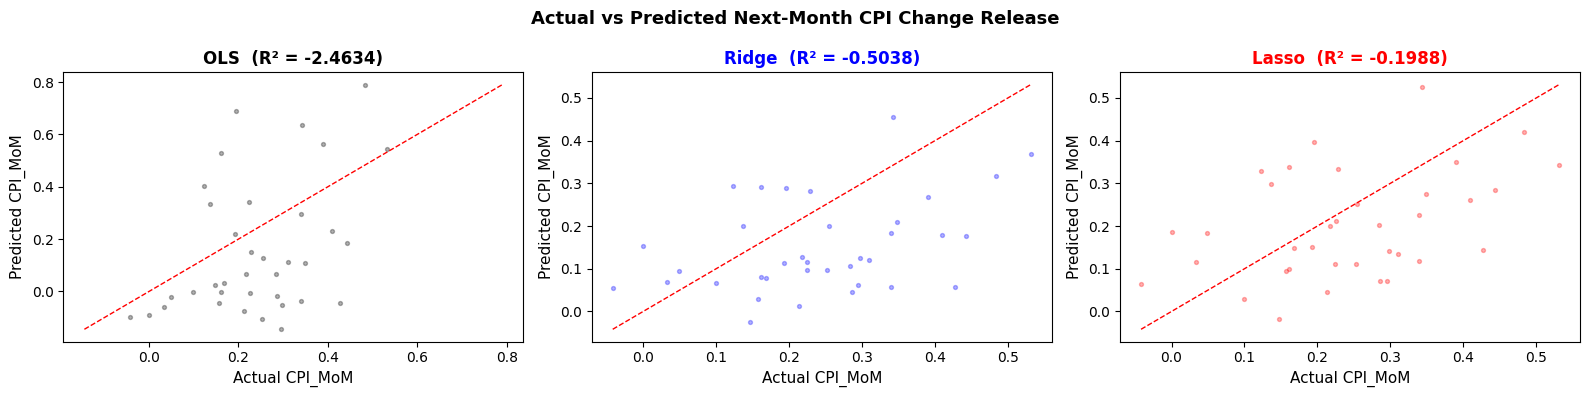

In [19]:
#plot predictions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, y_actual, y_pred, color) in zip(axes, [
    ("OLS",   y_test, y_pred_ols,   "black"),
    ("Ridge", y_test, y_pred_ridge_test, "blue"),
    ("Lasso", y_test, y_pred_lasso, "red")
]):
    y_actual_arr = np.array(y_actual)
    y_pred_arr   = np.array(y_pred)
    ax.scatter(y_actual_arr, y_pred_arr, alpha=0.3, s=8, color=color)
    lims = [min(y_actual_arr.min(), y_pred_arr.min()),
            max(y_actual_arr.max(), y_pred_arr.max())]
    ax.plot(lims, lims, "r--", lw=1, label="perfect")
    ax.set_xlabel("Actual CPI_MoM", fontsize=11)
    ax.set_ylabel("Predicted CPI_MoM", fontsize=11)
    r2_val = r2_score(y_actual_arr, y_pred_arr)
    ax.set_title(f"{name}  (R² = {r2_val:.4f})", fontsize=12, fontweight="bold", color=color)
plt.suptitle("Actual vs Predicted Next-Month CPI Change Release", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

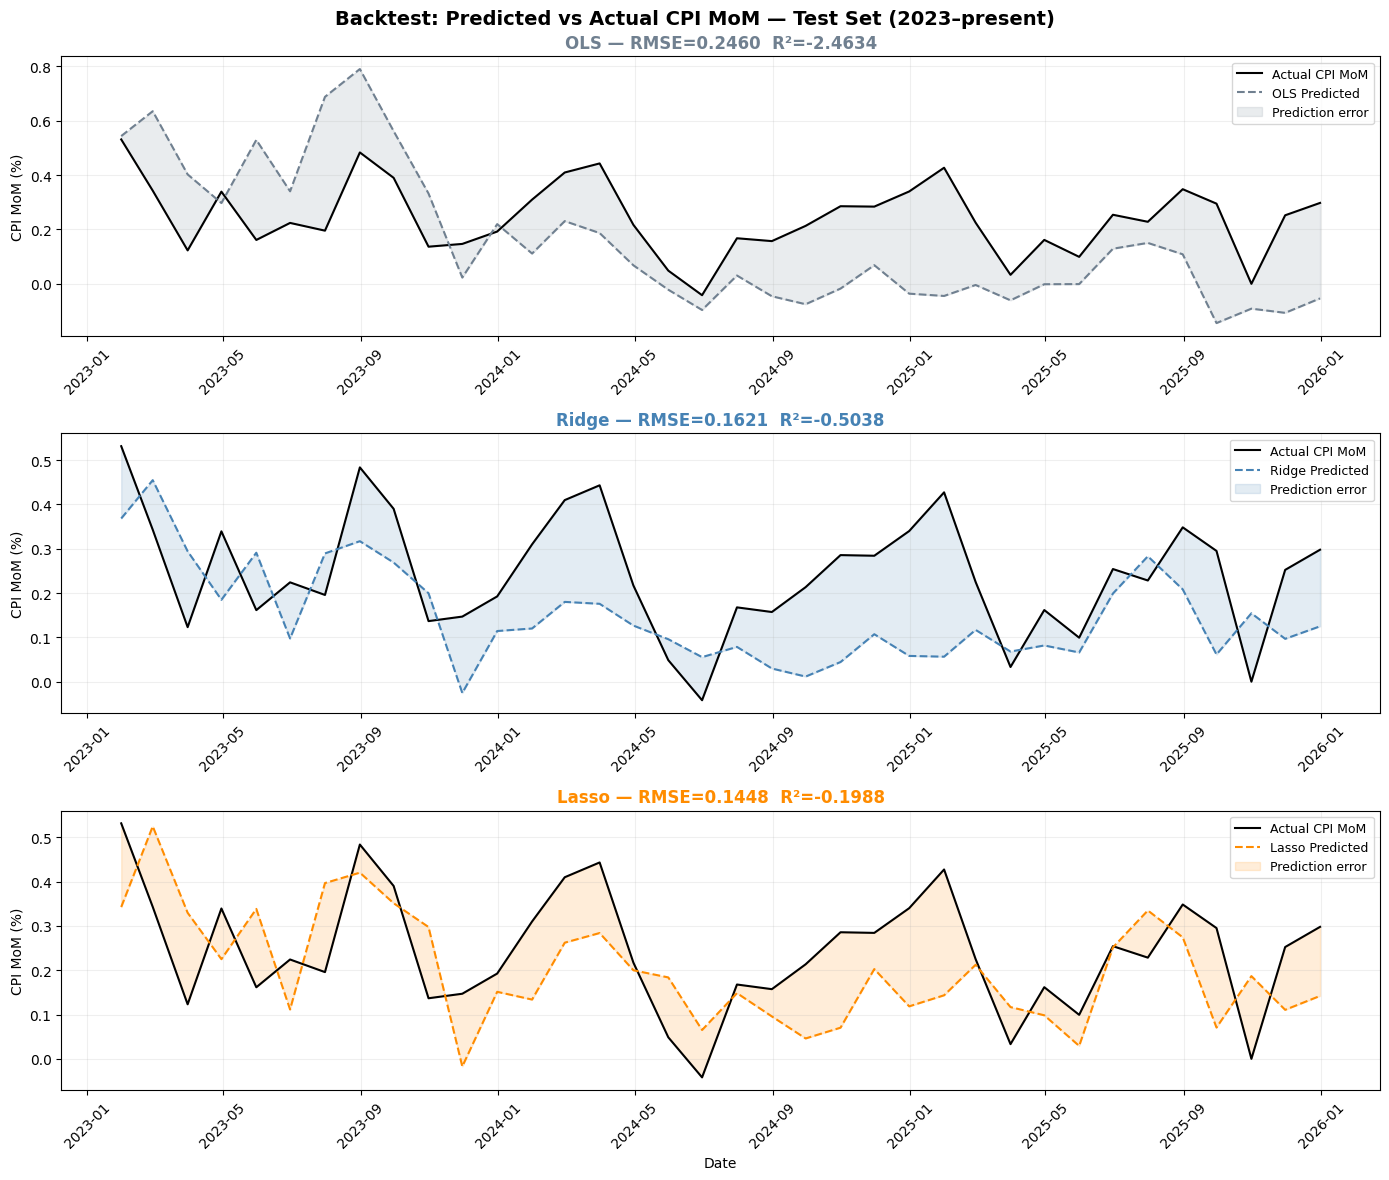

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

models_plot = [
    ("OLS",   y_test, y_pred_ols,         "slategray"),
    ("Ridge", y_test, y_pred_ridge_test,  "steelblue"),
    ("Lasso", y_test, y_pred_lasso,       "darkorange"),
]

for ax, (name, y_actual, y_pred, color) in zip(axes, models_plot):
    y_actual = np.array(y_actual)
    y_pred   = np.array(y_pred)
    dates    = y_test.index              # same for all three now

    ax.plot(dates, y_actual, color="black", lw=1.5, label="Actual CPI MoM")
    ax.plot(dates, y_pred,   color=color,   lw=1.5,
            linestyle="--", label=f"{name} Predicted")
    ax.fill_between(dates, y_actual, y_pred,
                    alpha=0.15, color=color, label="Prediction error")

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2   = r2_score(y_actual, y_pred)
    ax.set_title(f"{name} — RMSE={rmse:.4f}  R²={r2:.4f}",
                 fontsize=12, fontweight="bold", color=color)
    ax.set_ylabel("CPI MoM (%)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    ax.tick_params(axis="x", rotation=45)

axes[-1].set_xlabel("Date")
plt.suptitle("Backtest: Predicted vs Actual CPI MoM — Test Set (2023–present)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

A good way to plot uncertainty for these models is to run bootstrap iterations as saw in class in order to resample training data with replacement, refitting the model and plotting each prediction. It directly mirrors the theoretical motivation of possible 'worlds' the model could have been trained in. The spread of the lines reflect the uncertainity itself without requiring us to provide assumption regarding distribution assumptions and naturally provide time and context-varying uncertainty. 

Another approach could be to use standard deviation of the residuals and compute the uncertainty using a 95% prediction interval. However, some normality and zero centeredness assumptions would have been made. 

This will take maximum 2min to run...


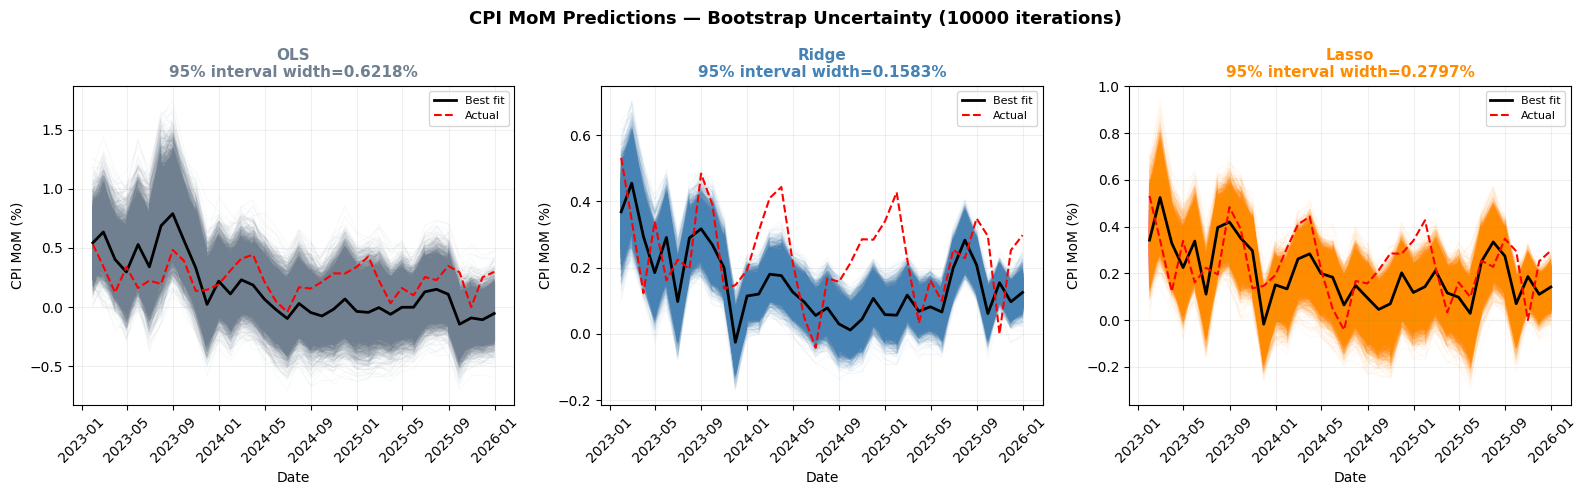

In [21]:
print('This will take maximum 2min to run...')

n_iterations = 10000          # 200 is visually identical to 10000, runs in seconds not minutes
test_dates   = y_test.index

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_config = [
    ("OLS",   LinearRegression(),                         X_train_scaled_full, X_test_scaled_full, y_pred_ols,         "slategray"),
    ("Ridge", Ridge(alpha=best_alpha_ridge),              X_train_scaled_full, X_test_scaled_full, y_pred_ridge_test,  "steelblue"),  # ← fixed
    ("Lasso", Lasso(alpha=best_alpha_lasso, max_iter=10000), X_train_scaled_full, X_test_scaled_full, y_pred_lasso,    "darkorange"),
]

for ax, (name, model, X_tr, X_te, y_pred_best, color) in zip(axes, models_config):

    boot_preds = np.zeros((n_iterations, len(X_te)))

    for i in range(n_iterations):
        X_boot, y_boot = resample(X_tr, y_train, random_state=i)
        model.fit(X_boot, y_boot)
        boot_preds[i] = model.predict(X_te)
        ax.plot(test_dates, boot_preds[i],
                color=color, alpha=0.05, linewidth=0.8)

    # Best fit line
    ax.plot(test_dates, np.array(y_pred_best),
            color="black", linewidth=2, label="Best fit", zorder=5)

    # Actual values
    ax.plot(test_dates, y_test.values,
            color="red", linewidth=1.5, linestyle="--",
            label="Actual", zorder=5)

    # 95% interval
    lower     = np.percentile(boot_preds, 2.5,  axis=0)
    upper     = np.percentile(boot_preds, 97.5, axis=0)
    avg_width = (upper - lower).mean()

    ax.fill_between(test_dates, lower, upper,
                    alpha=0.10, color=color)          # ← shaded band on top of lines

    ax.set_title(f"{name}\n95% interval width={avg_width:.4f}%",
                 fontsize=11, fontweight="bold", color=color)
    ax.set_xlabel("Date",         fontsize=10)
    ax.set_ylabel("CPI MoM (%)", fontsize=10)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle(
    f"CPI MoM Predictions — Bootstrap Uncertainty ({n_iterations} iterations)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

## Conclusion

In conclusion, the features selected for this modelization were a mix of the features suggested in the assignment and additional ones justified by economic reasoning. The cost-push channel was prioritized through exchange rates, import prices, oil and PPI — the latter being a novel addition not included in the original suggested list. PPI captures producer-level input costs that pass through to consumer prices with a lag of 2-3 months, increasing model explainability without meaningfully affecting MSE. Although PPI-derived features introduced internal collinearity across their multiple lags and rate-of-change transformations, this was handled through threshold-based collinearity filtering (PPI_YoY was dropped) and through regularization — noting that the most relevant features were ultimately captured through the top correlated features with the target.

Non-stationary raw level features were systematically dropped in favor of stationary transformations — growth rates, percentage changes, and first differences — in order to avoid spurious correlations driven by shared trends rather than genuine economic relationships. The target variable was defined as CPI month-over-month change rather than the CPI level, which would have produced artificially high R² by exploiting the series' persistence rather than genuine predictive signal.

TimeSeriesSplit cross-validation was used consistently across Ridge and Lasso for alpha selection, respecting the temporal ordering of the data and avoiding leakage from future observations into training folds. This ultimately confirmed Lasso as the most reliable model — its sparsity penalty zeroed out irrelevant features, retaining only the most informative subset, which proved advantageous for a noisy target like monthly CPI changes where many macro features carry weak and unstable signal.

Overall, each model reflects a different bias-variance tradeoff. OLS places no constraint on coefficients and is most sensitive to noise and multicollinearity. Ridge shrinks all coefficients smoothly but retains all features, performing well when signal is distributed broadly. Lasso performs hard feature selection, which is most appropriate when only a subset of features carries genuine predictive information — as is the case here. The combination of hypothesis testing, residual analysis, bootstrap uncertainty quantification, and regime-aware validation provides a statistically grounded framework for understanding not just what the models predict, but how much those predictions can be trusted across different economic environments.